GEOLOGICAL PLANE ANALYSIS TOOL
Enter strike angle (degrees, 0-360): 45
Enter dip angle (degrees, 0-90): 30
GEOLOGICAL PLANE ANALYSIS

Input Parameters:
  Strike: 45.0° (measured clockwise from North)
  Dip: 30.0° (measured downward from horizontal)
  Dip Direction: 135.0° (perpendicular to strike, 90° clockwise)


Normal Vector (perpendicular to plane):
  n = [ 0.3536, -0.3536,  0.8660]
  |n| = 1.000000 (unit vector)


Strike Vector (horizontal, along strike line):
  s = [ 0.7071,  0.7071,  0.0000]


Dip Vector (down-dip direction in plane):
  d = [ 0.6124, -0.6124, -0.5000]


Verification (should be near zero):
  n · s = 0.0000000000
  n · d = 0.0000000000
  s · d = 0.0000000000


Normal Vector Orientation:
  Trend: 135.00°
  Plunge: 60.00°


Generating visualizations...


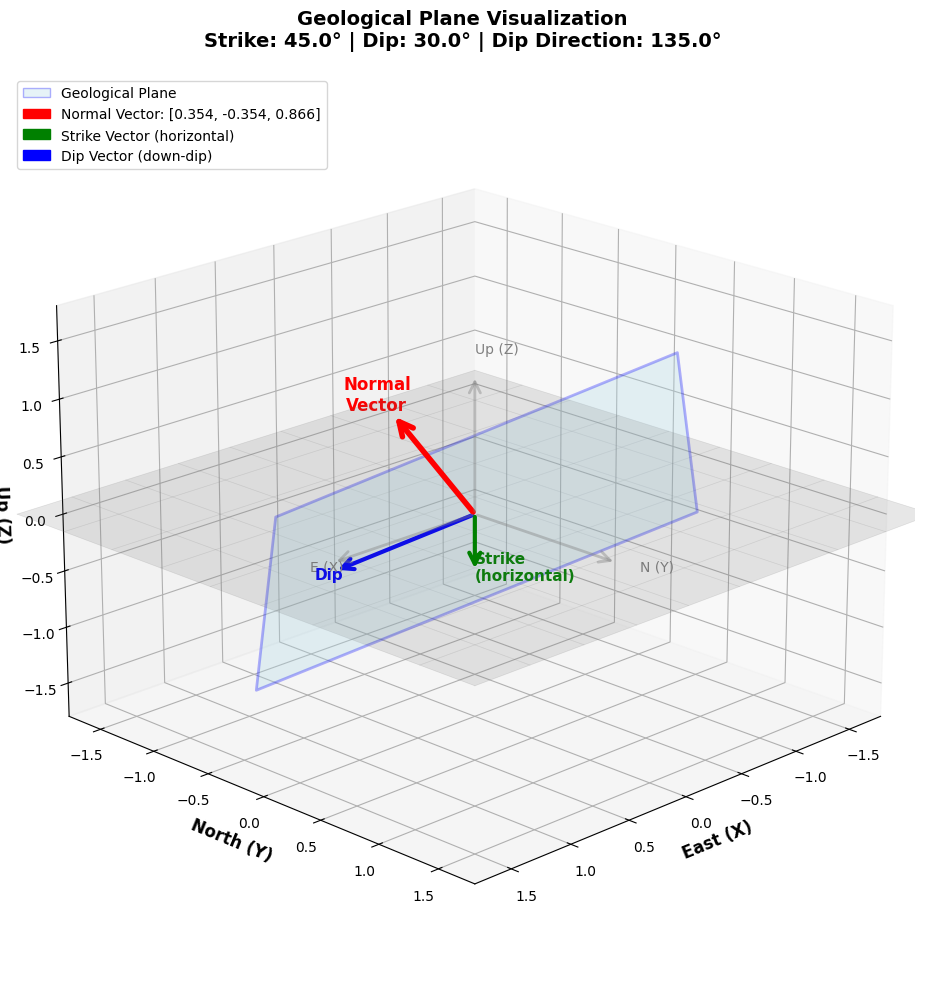

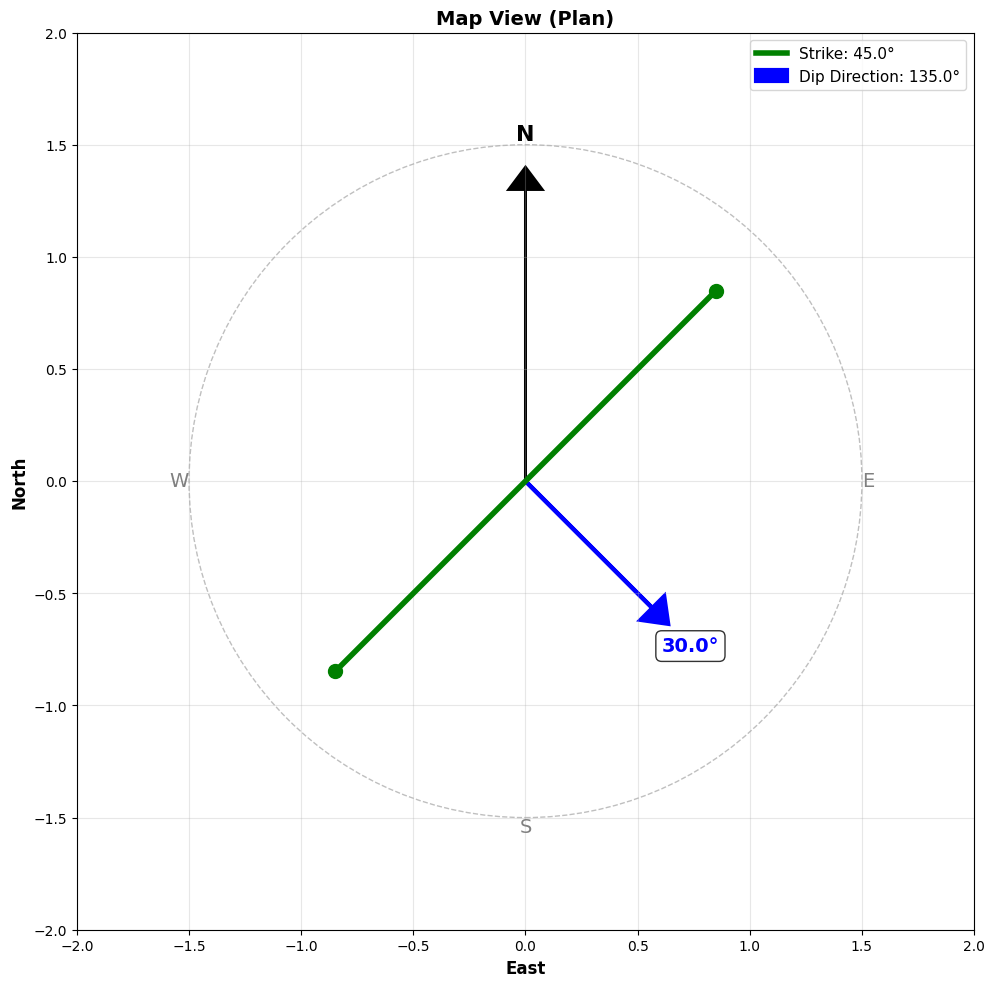

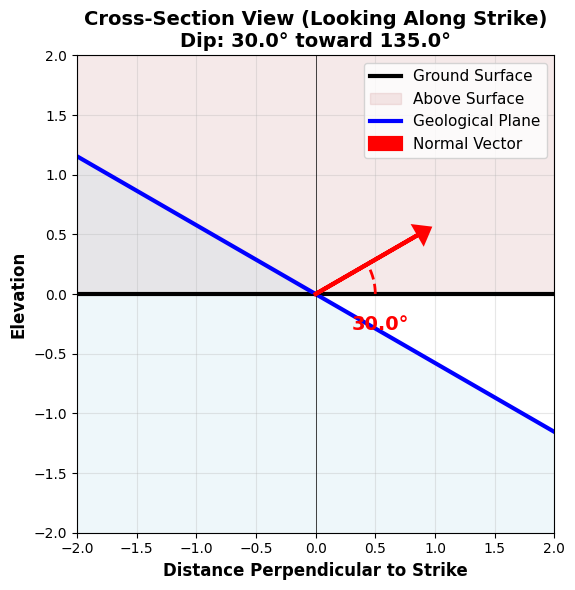

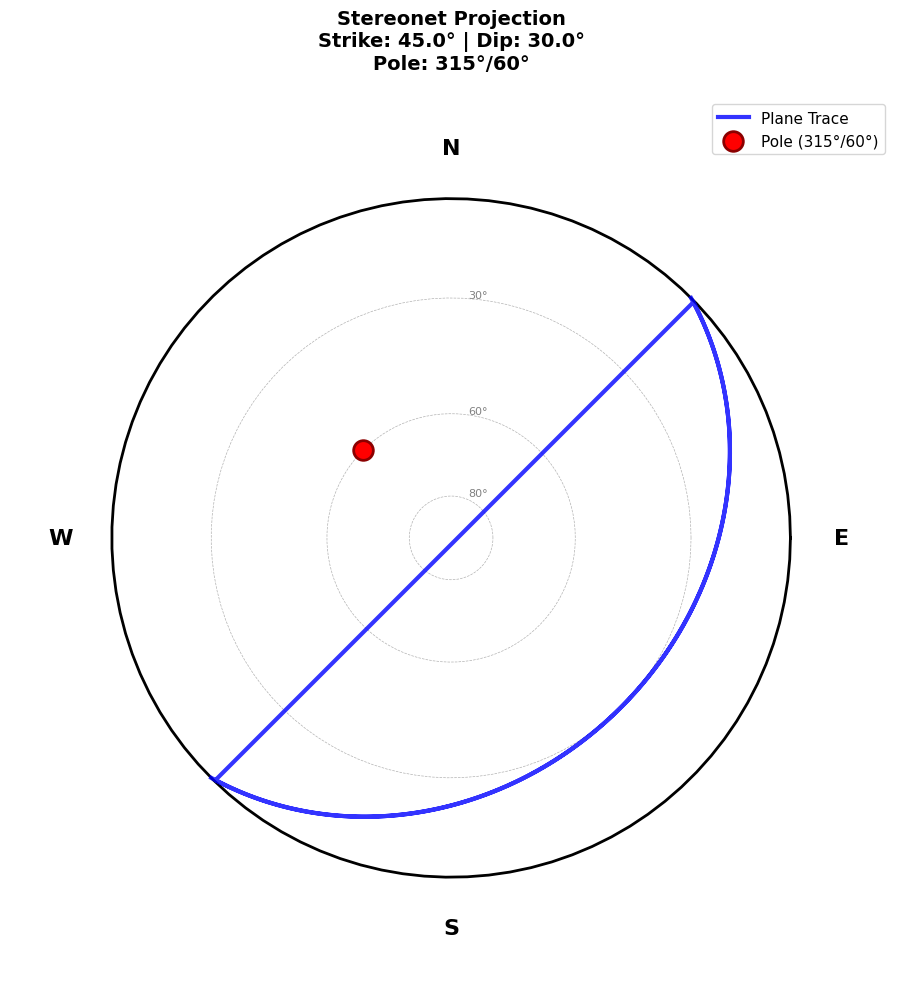


✓ All visualizations complete!
✓ Figures saved as PNG files


In [8]:
"""
Enhanced Geological Plane Analysis with 3D Visualization
Strike and Dip Analysis with Interactive Graphics
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

# Custom 3D arrow class for better visualization
class Arrow3D(FancyArrowPatch):
    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)
        
    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        
        return np.min(zs)

# ============================================================================
# CORE FUNCTIONS
# ============================================================================

def plane_normal(strike, dip):
    """
    Calculates the normal vector to a plane given its strike and dip.

    Parameters:
    -----------
    strike : float
        Strike angle in degrees (measured clockwise from North).
    dip : float
        Dip angle in degrees (measured downward from the horizontal).

    Returns:
    --------
    np.array
        A unit normal vector [nx, ny, nz] pointing UP from plane.
    """
    # Get strike and dip vectors
    s_vec = strike_vector(strike)
    d_vec = dip_vector(strike, dip)
    
    # Normal is the cross product: strike × dip
    normal = np.cross(s_vec, d_vec)
    
    # Normalize to unit vector
    normal = normal / np.linalg.norm(normal)
    
    # Flip to point upward if pointing down
    # (For visualization, we want normal pointing up from plane)
    if normal[2] < 0:
        normal = -normal
    
    return normal

def dip_direction(strike):
    """Calculate dip direction from strike (perpendicular, 90° clockwise)."""
    return (strike + 90) % 360

def strike_vector(strike):
    """Calculate the strike vector (horizontal vector along the strike line)."""
    strike_rad = np.radians(strike)
    sx = np.sin(strike_rad)  # East component
    sy = np.cos(strike_rad)  # North component
    sz = 0.0
    return np.array([sx, sy, sz])

def dip_vector(strike, dip):
    """Calculate the dip vector (down-dip direction in the plane)."""
    strike_rad = np.radians(strike)
    dip_rad = np.radians(dip)
    
    # Dip direction is 90° clockwise from strike
    dip_dir_rad = strike_rad + np.pi/2
    
    dx = np.cos(dip_rad) * np.sin(dip_dir_rad)  # East component
    dy = np.cos(dip_rad) * np.cos(dip_dir_rad)  # North component
    dz = -np.sin(dip_rad)
    
    return np.array([dx, dy, dz])

def create_plane_mesh(strike, dip, size=2.0):
    """
    Create a mesh representing the geological plane.
    
    Parameters:
    -----------
    strike : float
        Strike angle in degrees.
    dip : float
        Dip angle in degrees.
    size : float
        Size of the plane to visualize.
        
    Returns:
    --------
    vertices : np.array
        Array of vertices defining the plane.
    """
    # Get strike and dip vectors
    s_vec = strike_vector(strike)
    d_vec = dip_vector(strike, dip)
    
    # Create plane as a parallelogram
    vertices = np.array([
        -size * s_vec - size * d_vec,
        size * s_vec - size * d_vec,
        size * s_vec + size * d_vec,
        -size * s_vec + size * d_vec
    ])
    
    return vertices

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_geological_plane_3d(strike, dip, figsize=(14, 10)):
    """
    Create comprehensive 3D visualization of geological plane with all vectors.
    
    Parameters:
    -----------
    strike : float
        Strike angle in degrees.
    dip : float
        Dip angle in degrees.
    figsize : tuple
        Figure size.
    """
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Calculate vectors
    normal = plane_normal(strike, dip)
    strike_vec = strike_vector(strike)
    dip_vec = dip_vector(strike, dip)
    
    # Create plane mesh
    plane_vertices = create_plane_mesh(strike, dip, size=1.5)
    
    # Plot the plane
    plane = Poly3DCollection([plane_vertices], alpha=0.3, facecolor='lightblue', 
                            edgecolor='blue', linewidth=2)
    ax.add_collection3d(plane)
    
    # Plot coordinate system (light gray)
    arrow_props = dict(mutation_scale=20, arrowstyle='->', linewidth=2)
    
    # X-axis (East)
    ax.add_artist(Arrow3D(0, 0, 0, 1.2, 0, 0, **arrow_props, color='gray', alpha=0.4))
    ax.text(1.4, 0, 0, 'E (X)', fontsize=10, color='gray')
    
    # Y-axis (North)
    ax.add_artist(Arrow3D(0, 0, 0, 0, 1.2, 0, **arrow_props, color='gray', alpha=0.4))
    ax.text(0, 1.4, 0, 'N (Y)', fontsize=10, color='gray')
    
    # Z-axis (Up)
    ax.add_artist(Arrow3D(0, 0, 0, 0, 0, 1.2, **arrow_props, color='gray', alpha=0.4))
    ax.text(0, 0, 1.4, 'Up (Z)', fontsize=10, color='gray')
    
    # Add horizontal plane at z=0 for reference (more visible)
    # Create a grid
    h_size = 2.0
    h_grid = 10
    xx, yy = np.meshgrid(np.linspace(-h_size, h_size, h_grid), 
                         np.linspace(-h_size, h_size, h_grid))
    zz = np.zeros_like(xx)
    
    # Plot as semi-transparent surface
    ax.plot_surface(xx, yy, zz, alpha=0.15, color='gray', 
                   linewidth=0, antialiased=True, shade=True)
    
    # Add grid lines for better visibility
    for i in range(h_grid):
        ax.plot(xx[i, :], yy[i, :], zz[i, :], 'gray', alpha=0.2, linewidth=0.5)
        ax.plot(xx[:, i], yy[:, i], zz[:, i], 'gray', alpha=0.2, linewidth=0.5)
    
    # Plot normal vector (RED - most important)
    arrow_props_normal = dict(mutation_scale=25, arrowstyle='->', linewidth=4)
    ax.add_artist(Arrow3D(0, 0, 0, normal[0], normal[1], normal[2], 
                         **arrow_props_normal, color='red'))
    ax.text(normal[0]*1.2, normal[1]*1.2, normal[2]*1.2, 
            'Normal\nVector', fontsize=12, fontweight='bold', color='red',
            ha='center', va='center')
    
    # Plot strike vector (GREEN) - should be horizontal
    arrow_props_strike = dict(mutation_scale=20, arrowstyle='->', linewidth=3)
    ax.add_artist(Arrow3D(0, 0, 0, strike_vec[0], strike_vec[1], strike_vec[2],
                         **arrow_props_strike, color='green'))
    # Force label to be at z=0 to show it's horizontal
    ax.text(strike_vec[0]*1.15, strike_vec[1]*1.15, 0,
            'Strike\n(horizontal)', fontsize=11, fontweight='bold', color='green')
    
    # Plot dip vector (BLUE)
    arrow_props_dip = dict(mutation_scale=20, arrowstyle='->', linewidth=3)
    ax.add_artist(Arrow3D(0, 0, 0, dip_vec[0], dip_vec[1], dip_vec[2],
                         **arrow_props_dip, color='blue'))
    ax.text(dip_vec[0]*1.15, dip_vec[1]*1.15, dip_vec[2]*1.15,
            'Dip', fontsize=11, fontweight='bold', color='blue')
    
    # Set labels and title
    ax.set_xlabel('East (X)', fontsize=12, fontweight='bold')
    ax.set_ylabel('North (Y)', fontsize=12, fontweight='bold')
    ax.set_zlabel('Up (Z)', fontsize=12, fontweight='bold')
    
    title = f'Geological Plane Visualization\n'
    title += f'Strike: {strike}° | Dip: {dip}° | Dip Direction: {dip_direction(strike)}°'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Set equal aspect ratio and limits
    max_range = 1.8
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    
    # Set viewing angle
    ax.view_init(elev=20, azim=45)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Create custom legend
    legend_elements = [
        mpatches.Patch(facecolor='lightblue', edgecolor='blue', alpha=0.3, label='Geological Plane'),
        mpatches.Patch(color='red', label=f'Normal Vector: [{normal[0]:.3f}, {normal[1]:.3f}, {normal[2]:.3f}]'),
        mpatches.Patch(color='green', label='Strike Vector (horizontal)'),
        mpatches.Patch(color='blue', label='Dip Vector (down-dip)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    return fig, ax

def plot_stereonet(strike, dip, figsize=(10, 10)):
    """
    Create a lower-hemisphere equal-area stereonet projection.
    
    Parameters:
    -----------
    strike : float
        Strike angle in degrees.
    dip : float
        Dip angle in degrees.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get the actual normal vector (perpendicular to plane)
    normal = plane_normal(strike, dip)
    
    # For lower hemisphere, we need the downward-pointing normal
    # If normal points up (nz > 0), flip it
    if normal[2] > 0:
        normal = -normal
    
    # Calculate trend (azimuth) and plunge from the normal vector
    pole_trend = np.degrees(np.arctan2(normal[0], normal[1])) % 360
    pole_plunge = np.degrees(np.arcsin(-normal[2]))  # Negative because it points down
    
    # Equal-area projection for the pole
    r_pole = np.sqrt(2) * np.sin(np.radians(45 - pole_plunge/2))
    
    # Convert trend to Cartesian coordinates
    # In stereonet: North is +Y (up), East is +X (right)
    azimuth_rad = np.radians(pole_trend)
    x_pole = r_pole * np.sin(azimuth_rad)
    y_pole = r_pole * np.cos(azimuth_rad)
    
    # Outer circle
    theta_circle = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(theta_circle), np.sin(theta_circle), 
            'k-', linewidth=2)
    
    # Concentric circles (plunge lines)
    for plunge_line in [30, 60, 80]:
        r_line = np.sqrt(2) * np.sin(np.radians(45 - plunge_line/2))
        ax.plot(r_line * np.cos(theta_circle), r_line * np.sin(theta_circle),
                'k--', linewidth=0.5, alpha=0.3)
        ax.text(0.05, r_line, f'{plunge_line}°', fontsize=8, color='gray')
    
    # Calculate great circle (plane trace)
    gc_x = []
    gc_y = []
    
    # Calculate dip direction for the great circle
    dip_dir = dip_direction(strike)
    
    strike_rad = np.radians(strike)
    dip_rad = np.radians(dip)
    dip_azimuth_rad = np.radians(dip_dir)
    
    # Generate points on the great circle
    for angle in np.linspace(0, 2*np.pi, 200):
        # Two orthogonal unit vectors in the plane:
        # v1: along strike (horizontal)
        v1 = np.array([np.sin(strike_rad), np.cos(strike_rad), 0.0])
        
        # v2: down-dip direction (in the plane)
        v2 = np.array([
            np.cos(dip_rad) * np.sin(dip_azimuth_rad),
            np.cos(dip_rad) * np.cos(dip_azimuth_rad),
            -np.sin(dip_rad)
        ])
        
        # Point on the great circle
        p = np.cos(angle) * v1 + np.sin(angle) * v2
        
        # Normalize
        p = p / np.linalg.norm(p)
        px, py, pz = p
        
        # Lower hemisphere projection: project vectors pointing downward (pz <= 0)
        # If pointing up, reflect to lower hemisphere
        if pz > 0:
            px, py, pz = -px, -py, -pz
        
        # Calculate plunge for this point (angle below horizontal)
        point_plunge = np.degrees(np.arcsin(-pz))  # Negative because pz is negative
        
        # Equal-area projection
        r_point = np.sqrt(2) * np.sin(np.radians(45 - point_plunge/2))
        
        # Calculate azimuth (clockwise from North)
        point_azimuth = np.arctan2(px, py)
        
        gc_x.append(r_point * np.sin(point_azimuth))
        gc_y.append(r_point * np.cos(point_azimuth))
    
    if gc_x:
        ax.plot(gc_x, gc_y, 'b-', linewidth=3, label='Plane Trace', alpha=0.8)
    
    # Plot pole to plane
    ax.scatter([x_pole], [y_pole], s=200, c='red', marker='o',
               edgecolors='darkred', linewidth=2, 
               label=f'Pole ({int(pole_trend)}°/{int(pole_plunge)}°)', zorder=10)
    
    # Add cardinal directions
    ax.text(0, 1.15, 'N', fontsize=16, fontweight='bold', ha='center', va='center')
    ax.text(1.15, 0, 'E', fontsize=16, fontweight='bold', ha='center', va='center')
    ax.text(0, -1.15, 'S', fontsize=16, fontweight='bold', ha='center', va='center')
    ax.text(-1.15, 0, 'W', fontsize=16, fontweight='bold', ha='center', va='center')
    
    # Formatting
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Stereonet Projection\nStrike: {strike}° | Dip: {dip}°\nPole: {int(pole_trend)}°/{int(pole_plunge)}°',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11, loc='upper right')
    
    plt.tight_layout()
    return fig, ax

def plot_cross_section(strike, dip, figsize=(12, 6)):
    """
    Create a cross-section view perpendicular to strike.
    
    Parameters:
    -----------
    strike : float
        Strike angle in degrees.
    dip : float
        Dip angle in degrees.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create cross-section profile
    x = np.array([-2, 2])
    
    # Dip line
    y_surface = np.array([0, 0])
    dip_rad = np.radians(dip)
    y_plane = x * np.tan(dip_rad)
    
    # Plot surface
    ax.plot(x, y_surface, 'k-', linewidth=3, label='Ground Surface')
    ax.fill_between(x, y_surface, 2, alpha=0.1, color='brown', label='Above Surface')
    
    # Plot plane
    ax.plot(x, -y_plane, 'b-', linewidth=3, label='Geological Plane')
    ax.fill_between(x, -y_plane, -3, alpha=0.2, color='lightblue')
    
    # Plot dip angle
    arc_radius = 0.5
    arc_angles = np.linspace(0, -dip_rad, 50)
    arc_x = arc_radius * np.cos(arc_angles)
    arc_y = -arc_radius * np.sin(arc_angles)
    ax.plot(arc_x, arc_y, 'r--', linewidth=2)
    ax.text(0.3, -0.3, f'{dip}°', fontsize=14, fontweight='bold', color='red')
    
    # Plot normal vector
    normal_scale = 1.0
    normal = plane_normal(strike, dip)
    
    # In cross-section, we project normal onto the dip plane
    # The cross-section is perpendicular to strike, looking in dip direction
    dip_dir_rad = np.radians(strike + 90)
    normal_horizontal = np.cos(dip_rad)
    normal_vertical = np.sin(dip_rad)
    
    ax.arrow(0, 0, normal_horizontal * normal_scale, normal_vertical * normal_scale,
            head_width=0.15, head_length=0.1, fc='red', ec='red', linewidth=3,
            label='Normal Vector', zorder=5)
    
    # Formatting
    ax.set_xlabel('Distance Perpendicular to Strike', fontsize=12, fontweight='bold')
    ax.set_ylabel('Elevation', fontsize=12, fontweight='bold')
    ax.set_title(f'Cross-Section View (Looking Along Strike)\nDip: {dip}° toward {dip_direction(strike)}°',
                fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='upper right')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    
    plt.tight_layout()
    return fig, ax

def plot_map_view(strike, dip, figsize=(10, 10)):
    """
    Create a map view showing strike direction.
    
    Parameters:
    -----------
    strike : float
        Strike angle in degrees.
    dip : float
        Dip angle in degrees.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw compass rose
    ax.add_patch(plt.Circle((0, 0), 1.5, fill=False, color='gray', 
                           linestyle='--', linewidth=1, alpha=0.5))
    
    # North arrow
    ax.arrow(0, 0, 0, 1.3, head_width=0.15, head_length=0.1, 
            fc='black', ec='black', linewidth=2)
    ax.text(0, 1.5, 'N', fontsize=16, fontweight='bold', ha='center', va='bottom')
    
    # Cardinal directions
    ax.text(1.5, 0, 'E', fontsize=14, ha='left', va='center', color='gray')
    ax.text(-1.5, 0, 'W', fontsize=14, ha='right', va='center', color='gray')
    ax.text(0, -1.5, 'S', fontsize=14, ha='center', va='top', color='gray')
    
    # Strike line
    strike_rad = np.radians(strike)
    strike_length = 1.2
    
    # Strike vector components (measured clockwise from North)
    sx = strike_length * np.sin(strike_rad)
    sy = strike_length * np.cos(strike_rad)
    
    # Plot strike line (both directions)
    ax.plot([-sx, sx], [-sy, sy], 'g-', linewidth=4, label=f'Strike: {strike}°')
    ax.plot([-sx, sx], [-sy, sy], 'go', markersize=10)
    
    # Dip direction (perpendicular to strike, 90° clockwise)
    dip_dir = dip_direction(strike)
    dip_rad = np.radians(dip_dir)
    dip_length = 0.8
    
    dx = dip_length * np.sin(dip_rad)
    dy = dip_length * np.cos(dip_rad)
    
    # Plot dip direction arrow
    ax.arrow(0, 0, dx, dy, head_width=0.15, head_length=0.1,
            fc='blue', ec='blue', linewidth=3, label=f'Dip Direction: {dip_dir}°')
    
    # Add dip angle annotation
    ax.text(dx*1.3, dy*1.3, f'{dip}°', fontsize=14, fontweight='bold',
           color='blue', ha='center', va='center',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Formatting
    ax.set_xlabel('East', fontsize=12, fontweight='bold')
    ax.set_ylabel('North', fontsize=12, fontweight='bold')
    ax.set_title('Map View (Plan)', fontsize=14, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='upper right')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    
    plt.tight_layout()
    return fig, ax

def print_analysis(strike, dip):
    """Print comprehensive analysis of the geological plane."""
    normal = plane_normal(strike, dip)
    strike_vec = strike_vector(strike)
    dip_vec = dip_vector(strike, dip)
    dip_dir = dip_direction(strike)
    
    print("="*70)
    print("GEOLOGICAL PLANE ANALYSIS")
    print("="*70)
    print(f"\nInput Parameters:")
    print(f"  Strike: {strike}° (measured clockwise from North)")
    print(f"  Dip: {dip}° (measured downward from horizontal)")
    print(f"  Dip Direction: {dip_dir}° (perpendicular to strike, 90° clockwise)")
    
    print(f"\n\nNormal Vector (perpendicular to plane):")
    print(f"  n = [{normal[0]:7.4f}, {normal[1]:7.4f}, {normal[2]:7.4f}]")
    print(f"  |n| = {np.linalg.norm(normal):.6f} (unit vector)")
    
    print(f"\n\nStrike Vector (horizontal, along strike line):")
    print(f"  s = [{strike_vec[0]:7.4f}, {strike_vec[1]:7.4f}, {strike_vec[2]:7.4f}]")
    
    print(f"\n\nDip Vector (down-dip direction in plane):")
    print(f"  d = [{dip_vec[0]:7.4f}, {dip_vec[1]:7.4f}, {dip_vec[2]:7.4f}]")
    
    # Verify orthogonality
    print(f"\n\nVerification (should be near zero):")
    print(f"  n · s = {np.dot(normal, strike_vec):.10f}")
    print(f"  n · d = {np.dot(normal, dip_vec):.10f}")
    print(f"  s · d = {np.dot(strike_vec, dip_vec):.10f}")
    
    # Trend and plunge of normal
    trend = np.degrees(np.arctan2(normal[0], normal[1])) % 360
    plunge = 90 - np.degrees(np.arccos(normal[2]))
    
    print(f"\n\nNormal Vector Orientation:")
    print(f"  Trend: {trend:.2f}°")
    print(f"  Plunge: {plunge:.2f}°")
    
    print("\n" + "="*70)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Example: Get user input or use defaults
    print("GEOLOGICAL PLANE ANALYSIS TOOL")
    print("="*70)
    
    try:
        strike = float(input("Enter strike angle (degrees, 0-360): ") or "045")
        dip = float(input("Enter dip angle (degrees, 0-90): ") or "60")
        
        # Validate input
        if not (0 <= strike <= 360):
            raise ValueError("Strike must be between 0 and 360 degrees")
        if not (0 <= dip <= 90):
            raise ValueError("Dip must be between 0 and 90 degrees")
        
        # Print analysis
        print_analysis(strike, dip)
        
        # Create visualizations
        print("\nGenerating visualizations...")
        
        fig1, ax1 = plot_geological_plane_3d(strike, dip)
        plt.savefig('geological_plane_3d.png', dpi=300, bbox_inches='tight')
        
        fig2, ax2 = plot_map_view(strike, dip)
        plt.savefig('geological_plane_map.png', dpi=300, bbox_inches='tight')
        
        fig3, ax3 = plot_cross_section(strike, dip)
        plt.savefig('geological_plane_section.png', dpi=300, bbox_inches='tight')
        
        fig4, ax4 = plot_stereonet(strike, dip)
        plt.savefig('geological_plane_stereonet.png', dpi=300, bbox_inches='tight')
        
        plt.show()
        
        print("\n✓ All visualizations complete!")
        print("✓ Figures saved as PNG files")
        
    except ValueError as e:
        print(f"\n✗ Error: {e}")
        print("Please enter valid numerical values.")